# INTRODUÇÃO - **Cogumelos (Mushrooms)**

Este conjunto de dados foi publicado originalmente no livro The Audubon Society Field Guide to North American Mushrooms (1981) por G. H. Lincoff.   
Mais tarde, foi doado ao famoso repositório de Machine Learning da Universidade da Califórnia em Irvine (UCI Machine Learning Repository) por David Ahn.

O dataset descreve **amostras correspondentes a 23 espécies de cogumelos com brânquias da família Agaricaceae** (gêneros Agaricus e Lepiota). Porém, o autor **não especificou no dataset as espécies ou famílias de cada registro.**  
Cada espécime foi identificado como **comestível ou venenoso** (incluindo aqueles de mutabilidade desconhecida e não recomendados para consumo).


Este dataset **é composto 100% por variáveis categóricas**. O objetivo deste projeto é determinar quais características visuais ou de odor são os indicadores mais confiáveis para prever se um cogumelo selvagem é seguro para o consumo ou se é letal.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Carregar o dataset direto da web
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/mushrooms.csv"
df = pd.read_csv(url)

## **Formato Geral do Dataset**

In [ ]:
# Mostra as primeiras 10 linhas e o formato geral dos dados
print(f"O dataset possui {df.shape[0]} linhas e {df.shape[1]} colunas.\n")
df.head()

O dataset possui 8124 linhas e 23 colunas.



,type,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,stalk_surface_below_ring,stalk_color_above_ring,stalk_color_below_ring,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


## **Dicionário de Dados Completo (23 Colunas)**

**Variável Alvo:**
  - **type (Tipo / Classe):** Define a segurança do cogumelo.


**Características do Chapéu (Cap):**
  - **cap_shape (Formato do Chapéu):** O contorno superior do cogumelo.
  - **cap_surface (Superfície do Chapéu):** A textura externa do topo.
  - **cap_color (Cor do Chapéu):** A cor da cobertura superior.


**Características das Brânquias / Lamelas (Gills):**
  - **bruises (Manchas/Contusões):** Se o cogumelo muda de cor ou ganha manchas quando é tocado ou machucado.
  - **odor (Odor / Cheiro):** O aroma exalado pelo fungo.
  - **gill_attachment (Fixação das Brânquias):** Como as lamelas se prendem ao talo do cogumelo.
  - **gill_spacing (Espaçamento das Brânquias):** A distância entre cada lâmina sob o chapéu.
  - **gill_size (Tamanho das Brânquias):** A largura das lamelas.
  - **gill_color (Cor das Brânquias):** A coloração das lâminas inferiores.


**Características do Talo / Estipe (Stalk)**
  - **stalk_shape (Formato do Talo):** O comportamento do diâmetro do caule.
  - **stalk_root (Raiz do Talo):** A estrutura da base que se prende ao solo.
  - **stalk_surface_above_ring (Superfície do Talo Acima do Anel):** Textura do caule na parte superior.
  - **stalk_surface_below_ring (Superfície do Talo Abaixo do Anel):** Textura do caule na parte inferior.
  - **stalk_color_above_ring (Cor do Talo Acima do Anel):** Cor da metade superior do caule.
  - **stalk_color_below_ring (Cor do Talo Abaixo do Anel):** Cor da metade inferior do caule.


**Características do Véu e Anel (Veil / Ring)**
  - **veil_type (Tipo de Véu):** O tecido protetor que cobre as lamelas jovens.
  - **veil_color (Cor do Véu):** A cor dessa membrana protetora.
  - **ring_number (Quantidade de Anéis):** Quantas "saias" de tecido restaram no talo.
  - **ring_type (Tipo de Anel):** O formato visual do anel que ficou no talo.


**Características Microscópicas e de Ambiente**
  - **spore_print_color (Cor do Depósito de Espóros):** A cor do "pó" (sementes) que o cogumelo solta quando deixado sobre uma superfície. É um dos testes mais vitais na micologia real.
  - **population (População):** Como os cogumelos crescem agrupados.
  - **habitat (Região / Habitat):** O ecossistema onde o espécime foi coletado.

## **Dicionário de Dados - Tradução e Limpeza dos Dados**


Como podemos ver no formato geral, o dataset original conta **com 23 variáveis estruturadas.** Além disso, os dados brutos s**ão definidos somente com um caractere** (uma letra do alfabeto), o que torna a leitura confusa.

Para garantir a **viabilidade prática deste projeto** e simular uma situação real de sobrevivência em que **uma pessoa precisa tomar uma decisão rápida baseando-se no que vê e cheira, foram selecionadas 6 variáveis principais (tipo, odor, cor_chapeu, cor_branquias, cor_esporos e regiao)**.

Características microscópicas ou que exigem testes demorados de laboratório (como a stalk_root ou a veil_type) foram **deliberadamente descartadas para manter o modelo ágil e focado em inspeção visual imediata.**

In [ ]:

#Faz a cópias das colunas selecionadas e joga em df_filtrado
df_filtrado = df[['type', 'odor', 'cap_color', 'gill_color', 'habitat', 'spore_print_color']].copy()

#Tradução de comestível ou venenoso
df_filtrado['type'] = df_filtrado['type'].map({'e': 'Comestivel', 'p': 'Venenoso'})

#Tradução do odor do cogumelo
df_filtrado['odor'] = df_filtrado['odor'].map({
    'a': 'Almíscar', 'l': 'Anis', 'c': 'Creosoto', 'y': 'Peixe',
    'f': 'Fétido', 'm': 'Mofado', 'n': 'Nenhum', 'p': 'Pungente', 's': 'Picante'
})

#Tradução da cor do cgumelo
df_filtrado['cap_color'] = df_filtrado['cap_color'].map({
    'n': 'Castanho', 'b': 'Bege', 'c': 'Canela', 'g': 'Cinzento', 'r': 'Verde',
    'p': 'Rosa', 'u': 'Roxo', 'e': 'Vermelho', 'w': 'Branco', 'y': 'Amarelo'
})

#Traduzindo as cores das Branqueas/Ramelas
df_filtrado['gill_color'] = df_filtrado['gill_color'].map({
    'k': 'Preto', 'n': 'Castanho', 'b': 'Chocolate', 'h': 'Chocolate-Claro',
    'g': 'Cinzento', 'r': 'Verde', 'o': 'Laranja', 'p': 'Rosa', 'u': 'Roxo',
    'e': 'Vermelho', 'w': 'Branco', 'y': 'Amarelo'
})

#Traduzindo aonde ele cresce
df_filtrado['habitat'] = df_filtrado['habitat'].map({
    'g': 'Gramados', 'l': 'Folhas Mortas', 'm': 'Prados', 'p': 'Caminhos',
    'u': 'Urbano', 'w': 'Florestas', 'd': 'Madeira/Árvores'
})

#Traduzindo a cor dos esporos
df_filtrado['spore_print_color'] = df_filtrado['spore_print_color'].map({
    'k': 'Preto', 'n': 'Castanho', 'b': 'Chocolate', 'h': 'Chocolate-Claro',
    'r': 'Verde', 'o': 'Laranja', 'u': 'Roxo', 'w': 'Branco', 'y': 'Amarelo'
})

#Traduzindo os nomes das colunas
df_traduzido = df_filtrado.rename(columns={
    'type': 'tipo',
    'odor': 'odor',
    'cap_color': 'cor_chapeu',
    'gill_color': 'cor_branquias',
    'habitat': 'regiao',
    'spore_print_color': 'cor_esporos'
})

print(f"Ao final da tradução o dataset possui: {df_traduzido.shape[0]} linhas e {df_traduzido.shape[1]} colunas.\n")
df_traduzido.head()

Ao final da tradução o dataset possui: 8124 linhas e 6 colunas.



,tipo,odor,cor_chapeu,cor_branquias,regiao,cor_esporos
0,Venenoso,Pungente,Castanho,Preto,Urbano,Preto
1,Comestivel,Almíscar,Amarelo,Preto,Gramados,Castanho
2,Comestivel,Anis,Branco,Castanho,Prados,Castanho
3,Venenoso,Pungente,Branco,Castanho,Urbano,Preto
4,Comestivel,Nenhum,Cinzento,Preto,Gramados,Castanho


**Dicionário das colunas:**

  - **tipo:** Se é comestível ou venenoso - Variável Alvo.

  - **odor:** O cheiro do cogumelo (Almíscar, Anis, Fétido, Nenhum, Peixe, etc.).

  - **cor_chapel:** A cor do chapel do cogumelo (Castanho, Vermelho, Amarelo, Cinzento, etc.).

  - **cor_branquias:** É a parte de baixo do chapéu do cogumelo. Na biologia, a cor das branquias é um dos fatores mais usados por especialistas para identificar famílias de fungos venenosos.

  - **cor_esporos** A cor do Depósito de Espóros - cor do "pó" (sementes) que o cogumelo solta quando deixado sobre uma superfície. É um dos testes mais vitais na micologia real.

  - **regiao:** Se ele foi encontrado em florestas, gramados, caminhos urbanos, folhas mortas, etc. Isso traz o contexto do ambiente para o modelo.

## **Resumo das Variáveis**

In [ ]:
df_traduzido.describe()

,tipo,odor,cor_chapeu,cor_branquias,regiao,cor_esporos
count,8124,8124,8124,8124,8124,8124
unique,2,9,10,12,7,9
top,Comestivel,Nenhum,Castanho,Chocolate,Madeira/Árvores,Branco
freq,4208,3528,2284,1728,3148,2388


Como o dataset não possui valores numéricos, o Pandas calcula estatísticas focadas em frequência e diversidade, em vez de médias e medianas.

**count (Contagem):** O número total de registros válidos.

**unique (Únicos):** Quantas categorias/opções diferentes existem naquela coluna.

**top (Mais Frequente):** A categoria que mais se repete na coluna.

**freq (Frequência do Top):** Quantas vezes exatamente o valor do top apareceu.

## **Interpretação das colunas**

### **Coluna tipo:**
Existem 2 valores únicos (Comestível ou Venenoso). O mais frequente é o Comestível, aparecendo 4.208 vezes.

Isso nos revela que o dataset é equilibrado. Se 4.208 são comestíveis, o restante (8124 - 4208 = 3916) são venenosos. Há uma proporção de aproximadamente **51,8% comestíveis e 48,2% venenosos**.

### **Coluna odor:**
Apresenta 9 tipos de cheiros diferentes. **O mais comum é Nenhum (cogumelos sem cheiro), registrando 3.528 ocorrências.**  
Quase metade dos cogumelos estudados, **43,4%, não possui cheiro marcante.**

### **Coluna cor_chapeu:**
Com 10  variações de cores distintas. O chapéu de cor **Castanho é o mais comum, com 2.284 aparições, que corresponde a 28,1%**.

O ecossistema analisado é dominado por tons terrosos, porém analisar somente pelas cores não é suficiente para dar uma resposta definitiva sobre o perigo do cogumelo

### **Coluna cor_branquias:**
Com 12 variações de cores na parte inferior do chapéu. **O tom Chocolate é o mais comum, aparecendo 1.728 vezes, correspondente a 21,2%.**

Sendo a variável com maior número de valores únicos, ela traz uma riqueza visual enorme para o algoritmo criar ramificações detalhadas na árvore.

### **Coluna cor_esporos:**
O depósito de esporos apresenta uma diversidade alta, registrando 9 cores distintas no ecossistema avaliado. **A coloração mais frequente na base de dados é a Branco**, acumulando 2.388 aparições, **representando aproximadamente 29,4% do total de amostras**

Na micologia real, **a esporada** (técnica de deixar o chapéu do cogumelo soltar suas "sementes" microscópicas sobre uma superfície) **é o teste definitivo de laboratório para diferenciar espécies visualmente idênticas.**

O alto volume de esporos brancos servirá como uma pista crucial de desempate para o algoritmo quando os métodos puramente visuais e olfativos falharem.

### **Coluna regiao:**
Os cogumelos foram mapeados em 7 tipos de ambientes. **O habitat mais comum é em áreas de Madeira/Árvores, com 3.148 registros, representando 38,7%.**

A maior parte das coletas, ocorreu diretamente em troncos ou madeiras caídas, o que faz total sentido biológico para o desenvolvimento de fungos da família Agaricus e Lepiota.

## **Valores ausentes e Duplicados**

In [ ]:
print(f"Das colunas selecionadas o datset tem 0 linhas ausentes!")
print(df_traduzido.isnull().sum())
print(f"\nO dataser tem {df_traduzido.duplicated().sum()} valores duplicados.")

Das colunas selecionadas o datset tem 0 linhas ausentes!
tipo             0
odor             0
cor_chapeu       0
cor_branquias    0
regiao           0
cor_esporos      0
dtype: int64

O dataser tem 7750 valores duplicados.


Foram identificadas **7.750 linhas com combinações idênticas** de características após a seleção das 6 variáveis de interesse.  

**Optou-se por manter a totalidade dos dados, visto que não se tratam de erros de inserção ou falhas de sistema, mas sim de múltiplos espécimes reais coletados na natureza que compartilham atributos visuais semelhantes**.

A remoção dessas linhas descaracterizaria a frequência estatística do ecossistema e reduziria drasticamente a base de dados de 8.124 para apenas 374 registros, inviabilizando o aprendizado do modelo de Machine Learning.

## **Análise e Tratamento de Outliers**

**Por se tratar de um conjunto de dados composto integralmente por variáveis categóricas nominais, a identificação e o tratamento de outlier não são aplicáveis a este projeto.**

A existência de categorias com menor frequência de ocorrência na base, como os cogumelos com esporos verdes ou chapéu roxo, **não configura a presença de anomalias ou erros de inserção**, mas sim características biológicas reais de amostras raras na natureza. Portanto, **nenhum dado foi descartado ou modificado, garantindo a integridade do ecossistema.**

Como não existem atributos numéricos contínuos na base (como peso, altura ou dimensões), **a análise de distribuição e frequência foi realizada de forma correta através de Gráficos de Barras Cruzadas (countplots)**, que são as ferramentas científicas ideais para dados textuais.

## **Análises Bivariadas**

### **O Poder Preditivo do Odor**

O primeiro gráfico revela que **o Odor é um dos indicadores biológicos mais fortes e confiáveis do dataset.** Existe uma separação praticamente perfeita entre as classes:

- Cogumelos com odores classificados como Fétido, Peixe, Picante, Pungente,     Mofado ou Creosoto são 100% venenosos. Não há nenhuma barra de 'Comestível' nestas categorias.

- Cogumelos com odores de Almíscar ou Anis são 100% comestíveis.
- A única ambiguidade ocorre na categoria Nenhum (sem cheiro), onde a maior parte é comestível, mas ainda há uma parcela perigosa de espécimes venenosos.

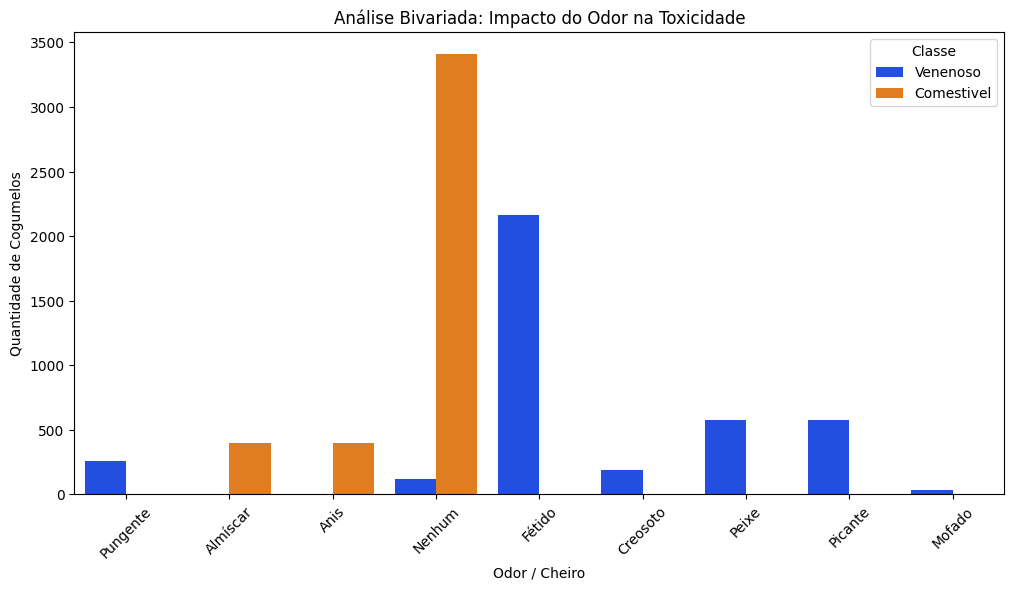

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df_traduzido, x='odor', hue='tipo', palette='bright')
plt.title('Análise Bivariada: Impacto do Odor na Toxicidade', fontsize=12)
plt.xlabel('Odor / Cheiro')
plt.ylabel('Quantidade de Cogumelos')
plt.xticks(rotation=45)
plt.legend(title='Classe')
plt.show()

### **A Incerteza da Cor do Chapéu**

O gráfico mostra que a Cor do Chapéu, isoladamente, **é um indicador fraco para tomada de decisão**. A cor mais comum, Castanho, possui uma distribuição muito equilibrada entre espécimes comestíveis e venenosos. O mesmo comportamento se repete para as cores Cinzento e Vermelho. Embora cores como Amarelo e Rosa tenham uma quantidade maior de espécimes venenosos, nenhuma cor garante 100% de certeza por si só.

Porem ao analisar o gráfico ainda é possível perceber que **cores mais terrosas e neutras (castanho, branco e sinza), tendem a ser mais comestíveis**, enquanto **os mais coloridos (amarelo, vermelho, rosa e bege), tendem a ser mais venenosos.**

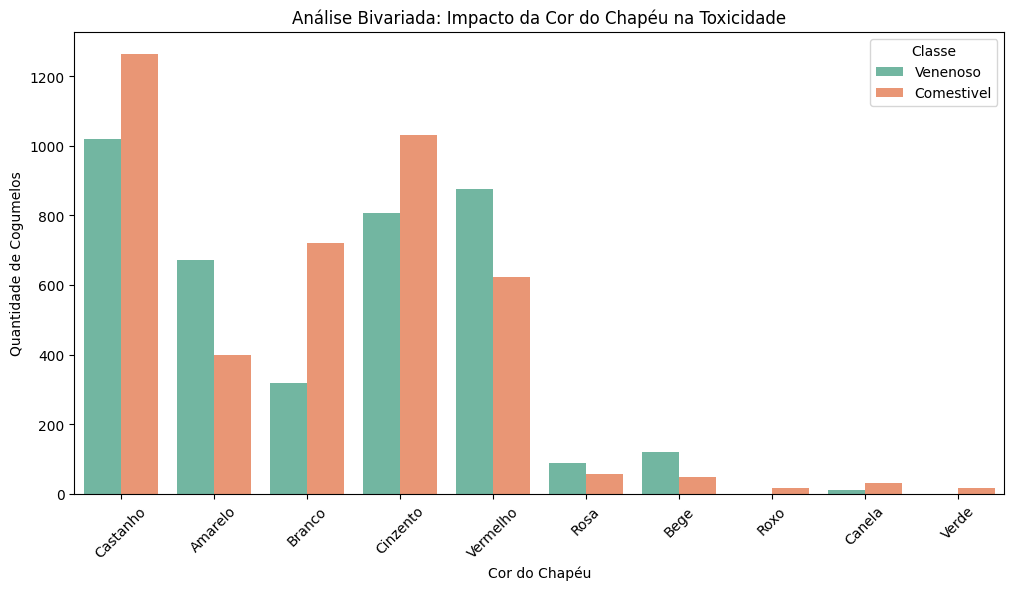

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df_traduzido, x='cor_chapeu', hue='tipo', palette='Set2')
plt.title('Análise Bivariada: Impacto da Cor do Chapéu na Toxicidade', fontsize=12)
plt.xlabel('Cor do Chapéu')
plt.ylabel('Quantidade de Cogumelos')
plt.xticks(rotation=45)
plt.legend(title='Classe')
plt.show()

### **Uma análise mais profunda - Cor das Brânquias**

As brânquias (as lâminas que ficam na parte de baixo do chapéu do cogumelo) são historicamente utilizadas por micologistas para identificar a toxicidade de fungos. No nosso conjunto de dados, **esta é a variável com maior diversidade, 12 categorias**, e ela **revela padrões muito mais agressivos e definitivos do que a cor do chapéu:**

  - **O Indicador de Perigo Absoluto (100% Venenoso):** Os cogumelos que possuem brânquias na cor Chocolate e Verde são 100% venenosos. Encontrar um espécime com essas cores de lamelas significa letalidade confirmada, tornando-se um forte critério de corte para o nosso modelo preditivo.

  - **O Indicador de Segurança Máxima (100% Comestível):** No extremo oposto, as brânquias nas cores Laranja e Vermelho são 100% comestíveis. Embora apareçam em menor quantidade na base de dados, elas são preditores perfeitos de segurança.

  - **Cores Fortemente Tendenciosas:** Brânquias de cor Castanho, Roxo e Preto apresentam uma esmagadora maioria de espécimes comestíveis. Já a cor Chocolate-Claro pende fortemente para o lado venenoso.

  - **A Ambiguidade das Cores Comuns:** As cores Branco, Cinzento e Rosa trazem grandes volumes de dados e estão presentes em ambas as classes, exigindo que o algoritmo investigue outras partes do cogumelo (como o odor) para tomar uma decisão final.

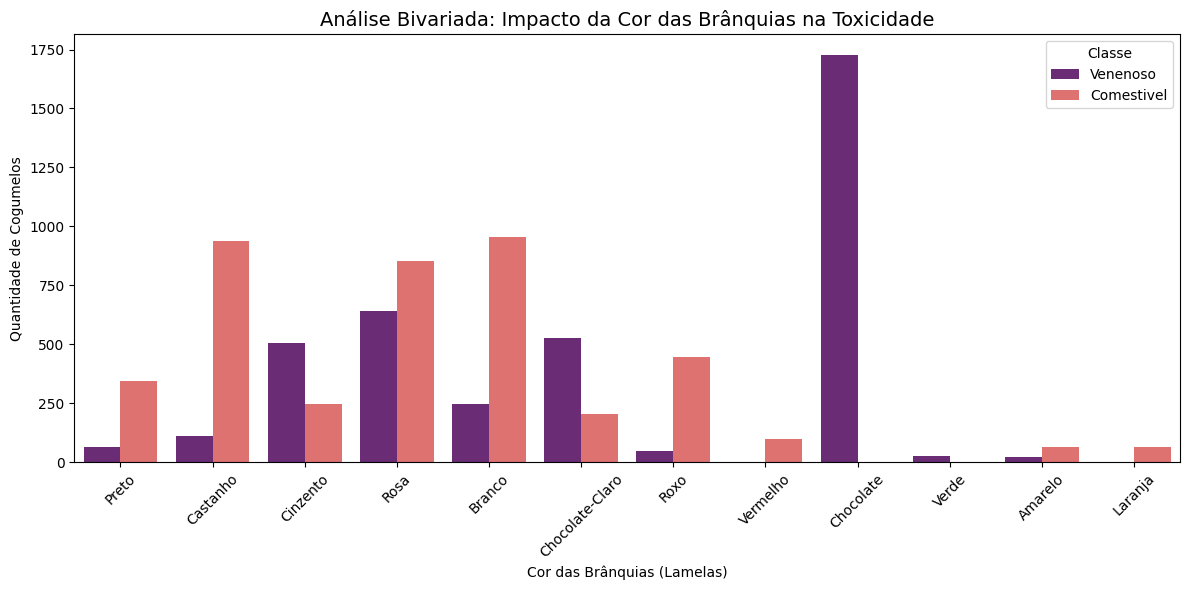

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df_traduzido, x='cor_branquias', hue='tipo', palette='magma')

plt.title('Análise Bivariada: Impacto da Cor das Brânquias na Toxicidade', fontsize=14)
plt.xlabel('Cor das Brânquias (Lamelas)')
plt.ylabel('Quantidade de Cogumelos')
plt.xticks(rotation=45)
plt.legend(title='Classe')
plt.tight_layout()
plt.show()

In [ ]:
# Tabela de porcentagem por cor de brânquia
tabela_branquias = pd.read_html(pd.crosstab(df_traduzido['cor_branquias'], df_traduzido['tipo'], normalize='index').to_html())[0]
tabela_branquias = (pd.crosstab(df_traduzido['cor_branquias'], df_traduzido['tipo'], normalize='index') * 100).sort_values(by='Venenoso', ascending=False)
tabela_branquias.round(1)

/tmp/ipykernel_24800/434182424.py:2: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tabela_branquias = pd.read_html(pd.crosstab(df_traduzido['cor_branquias'], df_traduzido['tipo'], normalize='index').to_html())[0]


tipo,Comestivel,Venenoso
cor_branquias,,
Chocolate,0.0,100.0
Verde,0.0,100.0
Chocolate-Claro,27.9,72.1
Cinzento,33.0,67.0
Rosa,57.1,42.9
Amarelo,74.4,25.6
Branco,79.5,20.5
Preto,84.3,15.7
Castanho,89.3,10.7


### **A Influência da Região**

O gráfico analisa o ambiente onde os fungos crescem e **revela padrões geográficos interessantes:**

  - Cogumelos encontrados em Caminhos e zonas Urbanas são majoritariamente venenosos. Ambientes impactados pela atividade humana parecem concentrar maior perigo.

  - Cogumelos que crescem em Prados e Florestas apresentam um comportamento misto.

  - Já os espécimes localizados em Madeira/Árvores mortas são, em sua grande maioria, seguros para o consumo (comestíveis).

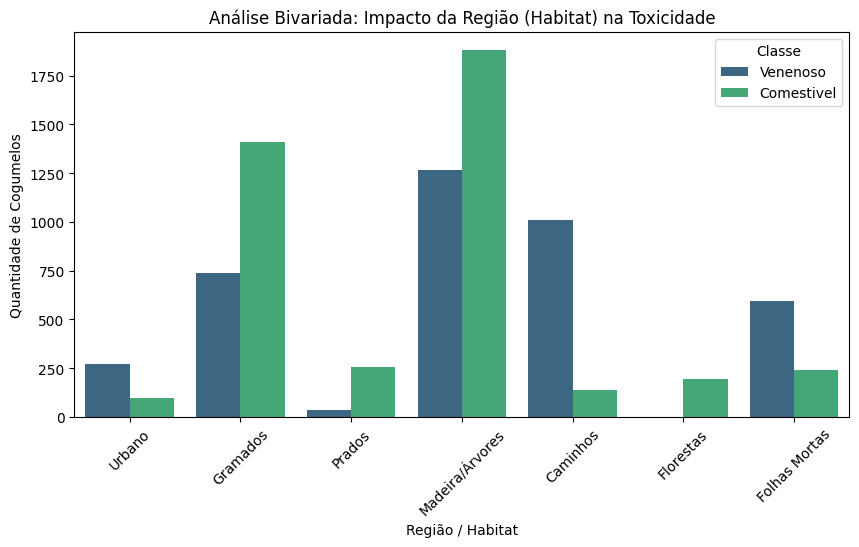

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df_traduzido, x='regiao', hue='tipo', palette='viridis')
plt.title('Análise Bivariada: Impacto da Região (Habitat) na Toxicidade', fontsize=12)
plt.xlabel('Região / Habitat')
plt.ylabel('Quantidade de Cogumelos')
plt.xticks(rotation=45)
plt.legend(title='Classe')
plt.show()

## **Análises Multivariadas**

#### **O Mistério dos Cogumelos Sem Cheiro**

Na análise bivariada, identificamos uma falha no indicador 'Odor': **os cogumelos classificados com odor Nenhum continham tanto espécimes comestíveis quanto venenosos**. Para solucionar esse problema e encontrar um padrão de sobrevivência, foi realizada uma **análise multivariada isolando apenas os cogumelos sem cheiro e cruzando-os com a Cor das Brânquias e a Classe (tipo)**, o resultado foi o seguinte:

  - Se o cogumelo não tem cheiro e possui brânquias nas cores preto, castanho, rosa, chocolate-claro, roxo, vermelho e laranja, **ele é 100% comestível**. O perigo desaparece completamente nessas combinações.

  - Se o cogumelo não tem cheiro e possui brânquias da cor Verde, **ele é 100% venenoso.**

  - Se o cogumelo não tem cheiro e possui brânquias nas cores cinzento, branco e amarelo, **há uma pequena chance de ainda ser venenoso.**



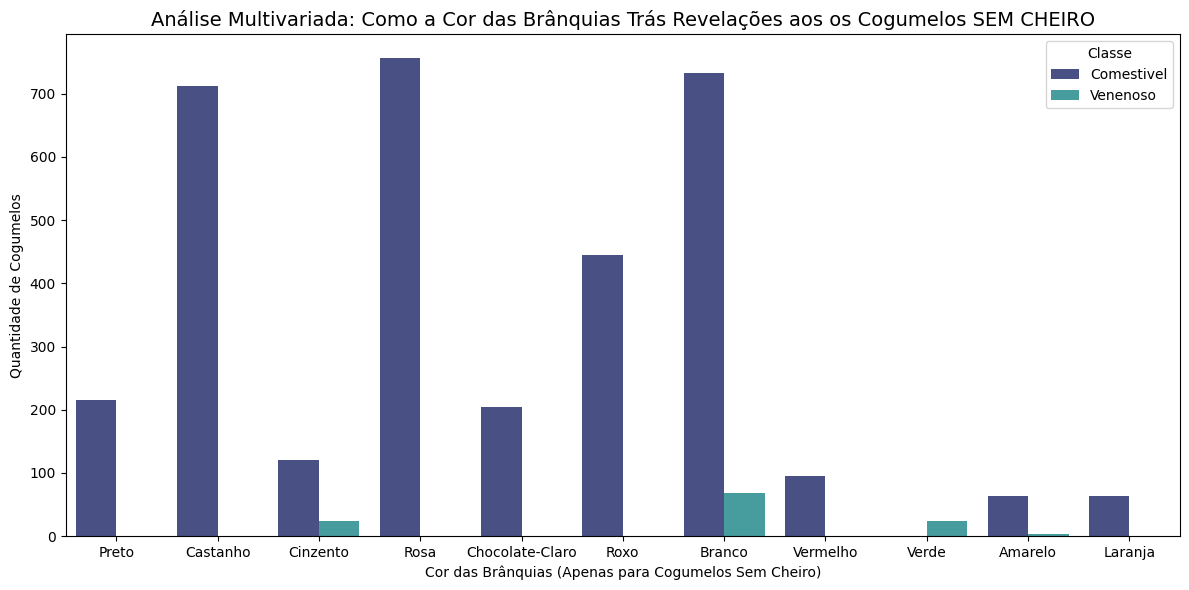

In [ ]:
# 1. Filtrar o dataset apenas para os cogumelos que NÃO têm cheiro
df_sem_cheiro = df_traduzido[df_traduzido['odor'] == 'Nenhum']

# 2. Gerar o gráfico multivariado
plt.figure(figsize=(12, 6))
sns.countplot(data=df_sem_cheiro, x='cor_branquias', hue='tipo', palette='mako')

plt.title('Análise Multivariada: Como a Cor das Brânquias Trás Revelações aos os Cogumelos SEM CHEIRO', fontsize=14)
plt.xlabel('Cor das Brânquias (Apenas para Cogumelos Sem Cheiro)')
plt.ylabel('Quantidade de Cogumelos')
plt.legend(title='Classe')
plt.tight_layout()
plt.show()

#### **Análise Multivariada - Aprofundamento nos Cogumelos Sem Odor com Brânqueas nas cores: Branca, Cinzento e Amarelo**

Ao aprofundar a análise multivariada anterior, detectou-se que ainda existiam cogumelos que **não possuem odor** e apresentam **brânquias nas cores Branco, Cinzento ou Amarelo** ainda continham uma mistura uma mistura de espécies venenosas e cosmetíveis.

Para tentar trazer mais clareza, foi introduzida uma terceira variável morfológica: **a Cor do Depósito de Esporos (cor_esporos).** O cruzamento dessas três variáveis simultâneas revelou o seguinte:

  - Dos cogumelos sem cheiro e com brânquias nas cores mencionadas, **se a cor dos esporos for Verde, o cogumelo é 100% venenoso.**

  - Se a cor dos esporos for: Preto, Castanho, Chocolate-Claro, Laranja, Chocolate e Amarelo, **os cogumelos são 100% comestíveis.**

  - Porem se as cores dos esporos for Branco, **ainda a uma mistura de cogumelhos comestíveis e venenosos, mesmo que em menor quantidade os venenosos.**

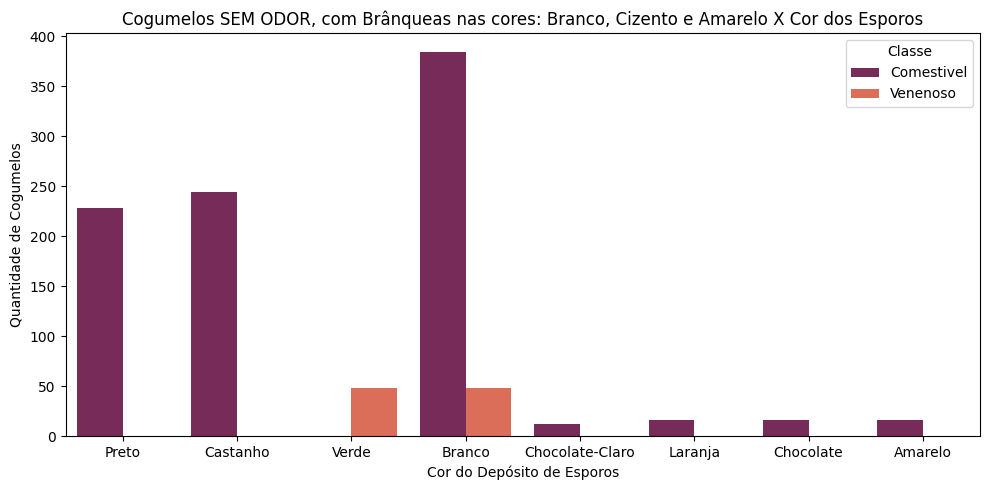

In [ ]:
# Filtrar: Apenas sem cheiro E com brânquias suspeitas (Branca, Cinzento, Amarelo)
df_suspeitos = df_traduzido[
    (df_traduzido['odor'] == 'Nenhum') &
    (df_traduzido['cor_branquias'].isin(['Branco', 'Cinzento', 'Amarelo']))
]

# Plotar o desempate final usando a Cor dos Esporos
plt.figure(figsize=(10, 5))
sns.countplot(data=df_suspeitos, x='cor_esporos', hue='tipo', palette='rocket')
plt.title('Cogumelos SEM ODOR, com Brânqueas nas cores: Branco, Cizento e Amarelo X Cor dos Esporos', fontsize=12)
plt.xlabel('Cor do Depósito de Esporos')
plt.ylabel('Quantidade de Cogumelos')
plt.legend(title='Classe')
plt.tight_layout()
plt.show()

#### **Análise Multivariada - O final**


Ao inspecionar o gráfico anterior, do terceiro nó, ainda é possível identificar que os cogumelos que possuem a **cor dos esporos Brancas, ainda continha uma mistura de venenosos ocultos sob uma maioria comestível**.

Para aumentar as chances de acerto **aplicou-se um quarto filtro utilizando a variável regiao (Habitat) especificamente sobre esse grupo ambíguo.**   

É possível observar os seguintes resultados:

  - Cogumelos sem odor, com brânqueas nas cores: Branco, Cinzento e Amarelo e esporos na cor Branca que crescem em regiões de Floresta, Gramados e Caminhos, são 100% comestíveis.

  - Não existem cogumelos nessas condições que nascem em Prados e meio Urbano.

  - Apesar de analisar 04 variáveis juntas, ainda temos uma mistura de espécies nos locais de Folhas Mortas e Madeira/Arvores, mesmo que em menor quantidade.


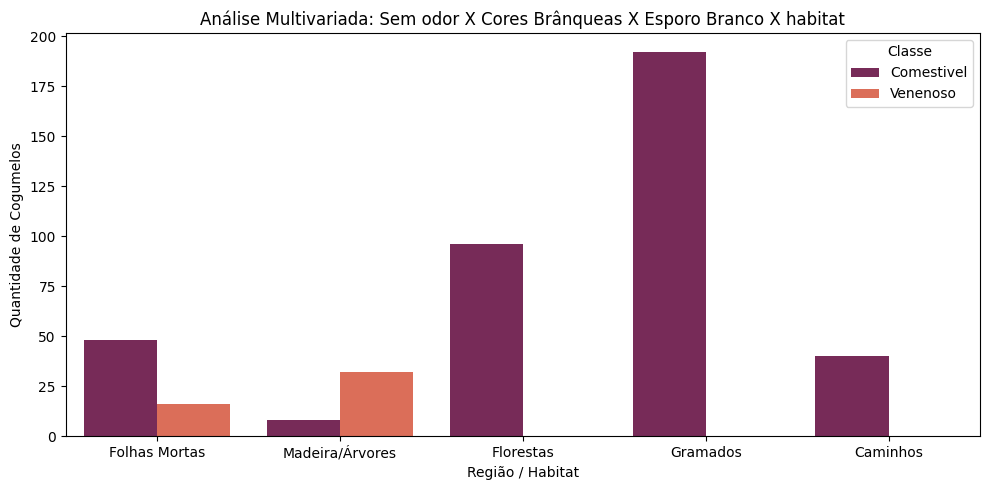

In [ ]:
# Filtrar: Sem cheiro + Brânquias suspeitas + Esporo Branco
df_branco = df_traduzido[
    (df_traduzido['odor'] == 'Nenhum') &
    (df_traduzido['cor_branquias'].isin(['Branco', 'Cinzento', 'Amarelo'])) &
    (df_traduzido['cor_esporos'] == 'Branco')
]

# Plotar o desempate final usando a Região
plt.figure(figsize=(10, 5))
sns.countplot(data=df_branco, x='regiao', hue='tipo', palette='rocket')
plt.title('Análise Multivariada: Sem odor X Cores Brânqueas X Esporo Branco X habitat', fontsize=12)
plt.xlabel('Região / Habitat')
plt.ylabel('Quantidade de Cogumelos')
plt.legend(title='Classe')
plt.tight_layout()
plt.show()

# **Insights, Hipóteses e Conclusões da EDA**



A realização desta Análise Exploratória de Dados (EDA) permitiu consolidar quatro insights fundamentais que guiarão a construção do modelo:

  - 1- **O Olfato é a Linha de Frente:** O odor funciona como o mecanismo de defesa natural mais poderoso. **Se um cogumelo exalar cheiros químicos ou desagradáveis, o diagnóstico de veneno é imediato.** O modelo de Machine Learning deve se aproveitar dessa pureza estatística e adotar o odor como o topo de sua estrutura (nó raiz).

  - 2- **A Visão Inicial Desorienta:** A cor do chapéu é uma armadilha visual. Por apresentar distribuições próximas a 50% de chance de erro nas cores mais comuns, **ela jamais deve ser usada de forma isolada para determinar o consumo seguro.**

  - 3- **A Resolução das Zonas Cinzentas:** Variáveis como cor_branquias e cor_esporos não servem apenas para classificação geral, **mas atuam como excelentes ferramentas de desempate** cirúrgico para os casos de cogumelos que não exalam nenhum cheiro.

  - 4- **O Limite Humano e a Necessidade da Árvore de Decisão:** A descoberta de que **mesmo após cruzar 4 variáveis simultâneas** (odor + cor_branquias + cor_esporos + regiao) **ainda restam sobreposições em habitats de Folhas Mortas e Madeira**, prova de forma empírica o limite do raciocínio humano a olho nu.

  O dataset apresenta **excelente qualidade técnica, volume robusto e comportamento equilibrado entre as classes.** A complexidade das regras condicionais e a existência de micro-padrões ocultos nas exceções dão total suporte e justifica a aplicação de um algoritmo de Árvore de Decisão, delegado para automatizar esses cruzamentos complexos e garantir uma taxa de acerto com risco zero.